# <span style="color:blue;font-weight:bold">Assignment 1.1 - Responsible AI Evaluation</span>

### **INFO3022 Advanced Topics in Data Analytics**

**Student:** Michael Hudson

**Dataset:** UCI Credit Card Default Dataset

**Date:** July 2026

---

### **Declaration**

I declare that the work hereby submitted is my own original work.

AI tools were used to assist with task interpretation, code explanations and debugging. All code, analysis and conclusions were reviewed and completed by me.

Python code was developed in a Jupyter Notebook using VS Code. Git was used for version control and all working files were maintained in a private GitHub repository.

<table>
<tr>
<td style="width:150px">
    <img src="Mike_Matrix.png" alt="Mike Matrix" width="150"/>
</td>
<td>
    I declare that the work hereby submitted is my own original work. Copilot was used for code completions but not used for code generation or to substitute for my own efforts in completing this assignment. ChatGPT5 was used for some task interpretation and code explanations. My Python code was created in a Jupyter Notebook using VS Code as the IDE. Git was used for version control and working docs were synced on GitHub in a <span style="color:orange; font-weight:bold">private</span> repository.
</td>
</tr>
</table>

### <span style="color:blue;font-weight:bold">1. Introduction</span>

### <span style="color:blue;font-weight:bold">2. Setup</span>

This section imports the Python libraries required for the analysis and loads the UCI Credit Card Default dataset into a pandas DataFrame.

**2.1 Import libraries**

In [1]:
# =================================================
# Import required libraries
# =================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

from fairlearn.postprocessing import ThresholdOptimizer

**2.2 Load dataset**

In [2]:
# =================================================
# Load the dataset
# =================================================

df = pd.read_csv("UCI_Credit_Card.csv")

### <span style="color:blue;font-weight:bold">3. Dataset Overview</span>

This section explores the structure and characteristics of the UCI Credit Card Default dataset. The aim is to understand the variables available, identify the prediction target, and examine the quality and composition of the data before building a baseline classification model.

In [4]:
# =================================================
# Dataset dimensions
# =================================================

print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Number of records: 30000
Number of features: 25


In [5]:
# =================================================
# Preview the dataset
# =================================================

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
# =================================================
# Data types and completeness
# =================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [17]:
# =================================================
# Variable types
# =================================================

print(df.dtypes)

ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object


The dataset contains a mixture of demographic, financial and repayment history variables. Although all variables are stored as numeric values, several represent categorical information encoded as integers (for example, sex, education and marital status), while others are continuous numerical measurements such as credit limit, bill amounts and payment amounts. This distinction is important because categorical and numerical variables require different preprocessing before model training.

In [7]:
# =================================================
# Summary statistics
# =================================================

df.describe(include='all')

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


The summary statistics indicate considerable variation in financial variables such as credit limit, bill amounts and payment amounts, reflecting the diverse financial circumstances of customers represented in the dataset. These differences are expected in real-world lending data and motivate the use of feature scaling during model development.

In [8]:
# =================================================
# Missing values
# =================================================

missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

No missing values were identified in the dataset. Consequently, no imputation was required. However, the absence of missing values does not necessarily imply that the data are free from quality issues, as encoded categories and historical biases may still influence model behaviour.

In [11]:
# =================================================
# Target variable
# =================================================

target = 'default.payment.next.month'

print(df[target].value_counts())
print(df[target].value_counts(normalize=True) * 100)

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [13]:
# =================================================
# Variable types
# =================================================

categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

numerical_cols = [
    col for col in df.columns if col not in categorical_cols + [target]
]

print(f"Categorical columns: {categorical_cols}")
print(f"Number of categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {numerical_cols}")
print(f"Number of numerical columns: {len(numerical_cols)}")

Categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE']
Number of categorical columns: 3
Numerical columns: ['ID', 'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Number of numerical columns: 21


The dataset contains **30,000 customer records** and **25 variables**, with each record representing an individual credit card customer. The variables include demographic characteristics (such as sex, education and marital status), financial information (credit limit, bill amounts and payment amounts), and repayment history over the previous six months. The prediction target is **`default.payment.next.month`**, indicating whether the customer defaulted on their next payment. No data cleaning was performed, consistent with the assignment instructions, although any limitations identified are discussed later as potential Responsible AI risks.

**Distribution of the Target Variable**

The target variable (`default.payment.next.month`) records whether a customer defaulted on their next credit card payment. Examining its distribution provides an indication of whether the dataset is balanced before model development.

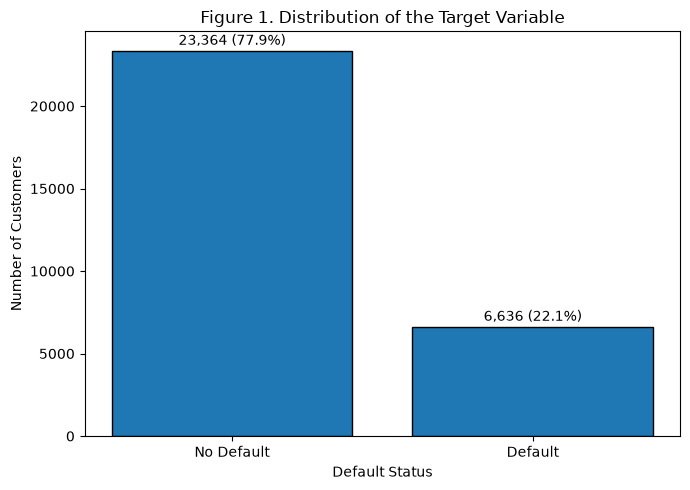

In [16]:
# =================================================
# Distribution of the target variable
# =================================================

# Count the number of observations in each class
target_counts = df[target].value_counts().sort_index()

# Calculate percentages
target_percentages = target_counts / target_counts.sum() * 100

# Create labels for the classes
labels = ["No Default", "Default"]

# Create the figure
plt.figure(figsize=(7, 5))

bars = plt.bar(labels, target_counts, edgecolor="black")

# Add the count and percentage above each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 150,
        f"{target_counts.iloc[i]:,} ({target_percentages.iloc[i]:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Figure 1. Distribution of the Target Variable")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Figure 1. Distribution of the target variable**

Figure 1 shows that the dataset contains substantially more customers who did **not** default than customers who **did** default on their next payment. This indicates that the prediction task is moderately imbalanced, an important consideration when evaluating model performance because overall accuracy alone may not adequately reflect performance on the minority class. This class distribution will also be considered when interpreting the fairness metrics in later sections.

In [18]:
# =================================================
# Key variables used in this study
# =================================================

key_variables = pd.DataFrame({
    "Variable": [
        "SEX",
        "AGE",
        "EDUCATION",
        "MARRIAGE",
        "default.payment.next.month"
    ],
    "Purpose": [
        "Protected attribute for fairness analysis",
        "Demographic characteristic",
        "Socio-economic characteristics",
        "Demographic characteristic",
        "Prediction target"
    ]
})

key_variables

,Variable,Purpose
0,SEX,Protected attribute for fairness analysis
1,AGE,Demographic characteristic
2,EDUCATION,Socio-economic characteristics
3,MARRIAGE,Demographic characteristic
4,default.payment.next.month,Prediction target


In [19]:
# =================================================
# Define key variables used throughout the notebook
# =================================================

TARGET = "default.payment.next.month"
PROTECTED_ATTRIBUTE = "SEX"
FEATURES = df.drop(columns=[TARGET])
LABEL = df[TARGET]

SEX_LABELS = {
    1: "Male",
    2: "Female"
}

### <span style="color:blue;font-weight:bold">4. What the Outcome Measures</span>

### <span style="color:blue;font-weight:bold">5. Subgroup Representation</span>

### <span style="color:blue;font-weight:bold">6. Baseline Model and Fairness Analysis</span>

### <span style="color:blue;font-weight:bold">7. Responsible AI Risks</span>

### <span style="color:blue;font-weight:bold">8. Foundation Model Alternative</span>

### <span style="color:blue;font-weight:bold">9. Recommendation</span>

### <span style="color:blue;font-weight:bold">10. References</span>

### <span style="color:blue;font-weight:bold">11. Appendix</span>